# Data Exploration: Medical Procedure Loan Default Risk

**Objective:** Understand the structure, quality, and characteristics of the application and bureau datasets to inform downstream data preparation and feature engineering for a medical procedure loan credit scorecard.

**Structure:**
- **Part A: Application Data** â€” applicant demographics, financials, target distribution, data quality
- **Part B: Bureau Data** â€” credit history records, aggregated patterns, risk signals

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Load datasets
app = pd.read_csv('../data/IS453 Group Assignment - Application Data.csv')
bureau = pd.read_csv('../data/IS453 Group Assignment - Bureau Data.csv')

print(f"Application data: {app.shape[0]:,} rows x {app.shape[1]} columns")
print(f"Bureau data:      {bureau.shape[0]:,} rows x {bureau.shape[1]} columns")

Application data: 307,511 rows x 120 columns
Bureau data:      1,716,428 rows x 17 columns


---
# Part A: Application Data Analysis

## A1. Target Variable

Non-defaulters (0): 91.93%
Defaulters (1):     8.07%
Imbalance ratio:    11.4:1


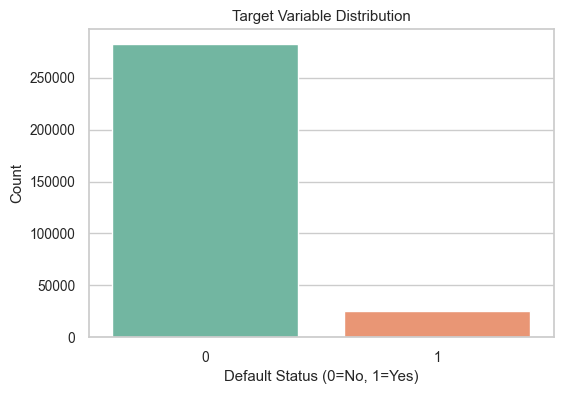

In [ ]:
target_dist = app['TARGET'].value_counts(normalize=True)
print(f"Non-defaulters (0): {target_dist[0]*100:.2f}%")
print(f"Defaulters (1):     {target_dist[1]*100:.2f}%")
print(f"Imbalance ratio:    {target_dist[0]/target_dist[1]:.1f}:1")

plt.figure(figsize=(6, 4))
sns.countplot(data=app, x='TARGET', hue='TARGET', palette='Set2', legend=False)
plt.title('Target Variable Distribution')
plt.xlabel('Default Status (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

## A2. Data Quality

Top Features with Missing Values:
  COMMONAREA_AVG                            69.87%
  COMMONAREA_MODE                           69.87%
  COMMONAREA_MEDI                           69.87%
  NONLIVINGAPARTMENTS_AVG                   69.43%
  NONLIVINGAPARTMENTS_MODE                  69.43%
  NONLIVINGAPARTMENTS_MEDI                  69.43%
  FONDKAPREMONT_MODE                        68.39%
  LIVINGAPARTMENTS_AVG                      68.35%
  LIVINGAPARTMENTS_MEDI                     68.35%
  LIVINGAPARTMENTS_MODE                     68.35%
  FLOORSMIN_MODE                            67.85%
  FLOORSMIN_AVG                             67.85%
  FLOORSMIN_MEDI                            67.85%
  YEARS_BUILD_AVG                           66.50%
  YEARS_BUILD_MODE                          66.50%


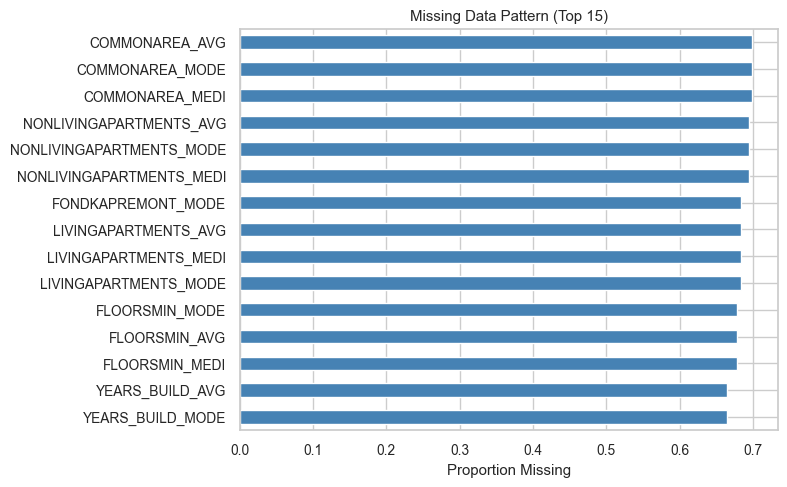

In [ ]:
# Top features with missing values
missing = app.isnull().mean().sort_values(ascending=False).head(15)
missing = missing[missing > 0]

if len(missing) > 0:
    print("Top Features with Missing Values:")
    for col, pct in missing.items():
        print(f"  {col:40s} {pct*100:6.2f}%")

    plt.figure(figsize=(8, 5))
    missing.plot.barh(color='steelblue')
    plt.xlabel('Proportion Missing')
    plt.title('Missing Data Pattern (Top 15)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [ ]:
summary = pd.DataFrame({
    'dtype': app.dtypes,
    'non_null': app.count(),
    'unique': app.nunique(),
    'null_pct': app.isnull().mean() * 100
})
print(f"Numeric columns:     {(summary['dtype'] == 'float64').sum() + (summary['dtype'] == 'int64').sum()}")
print(f"Categorical columns: {(summary['dtype'] == 'object').sum()}")
print(f"\n{summary.head(15)}")

Numeric columns:     104
Categorical columns: 16

                       dtype  non_null  unique  null_pct
SK_ID_CURR             int64    307511  307511  0.000000
TARGET                 int64    307511       2  0.000000
NAME_CONTRACT_TYPE    object    307511       2  0.000000
CODE_GENDER           object    307511       3  0.000000
FLAG_OWN_CAR          object    307511       2  0.000000
FLAG_OWN_REALTY       object    307511       2  0.000000
CNT_CHILDREN           int64    307511      15  0.000000
AMT_INCOME_TOTAL     float64    307511    2548  0.000000
AMT_CREDIT           float64    307511    5603  0.000000
AMT_ANNUITY          float64    307499   13672  0.003902
AMT_GOODS_PRICE      float64    307233    1002  0.090403
NAME_TYPE_SUITE       object    306219       7  0.420148
NAME_INCOME_TYPE      object    307511       8  0.000000
NAME_EDUCATION_TYPE   object    307511       5  0.000000
NAME_FAMILY_STATUS    object    307511       6  0.000000


## A3. Key Feature Distributions

In [ ]:
numeric_cols = app.select_dtypes(include=[np.number]).columns
app[numeric_cols].describe().round(2)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.00,307511.00,307511.00,3.075110e+05,307511.00,307499.00,307233.00,307511.00,307511.00,307511.00,...,307511.00,307511.00,307511.00,307511.00,265992.00,265992.00,265992.00,265992.00,265992.00,265992.00
mean,278180.52,0.08,0.42,1.687979e+05,599026.00,27108.57,538396.21,0.02,-16037.00,63815.05,...,0.01,0.00,0.00,0.00,0.01,0.01,0.03,0.27,0.27,1.90
std,102790.18,0.27,0.72,2.371231e+05,402490.78,14493.74,369446.46,0.01,4363.99,141275.77,...,0.09,0.02,0.02,0.02,0.08,0.11,0.20,0.92,0.79,1.87
min,100002.00,0.00,0.00,2.565000e+04,45000.00,1615.50,40500.00,0.00,-25229.00,-17912.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,189145.50,0.00,0.00,1.125000e+05,270000.00,16524.00,238500.00,0.01,-19682.00,-2760.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,278202.00,0.00,0.00,1.471500e+05,513531.00,24903.00,450000.00,0.02,-15750.00,-1213.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
75%,367142.50,0.00,1.00,2.025000e+05,808650.00,34596.00,679500.00,0.03,-12413.00,-289.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00
max,456255.00,1.00,19.00,1.170000e+08,4050000.00,258025.50,4050000.00,0.07,-7489.00,365243.00,...,1.00,1.00,1.00,1.00,4.00,9.00,8.00,27.00,261.00,25.00


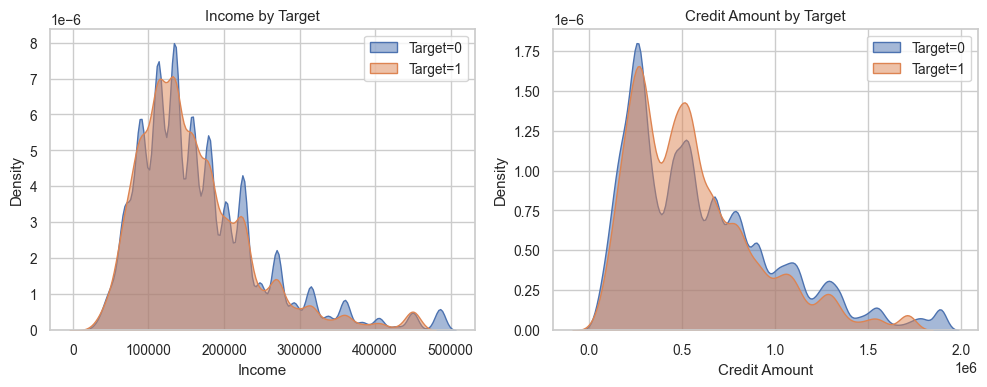

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for t in [0, 1]:
    s = app.loc[app['TARGET'] == t, 'AMT_INCOME_TOTAL']
    sns.kdeplot(s.clip(upper=s.quantile(0.99)), label=f'Target={t}', fill=True, alpha=0.5)
plt.title('Income by Target')
plt.xlabel('Income')
plt.legend()

plt.subplot(1, 2, 2)
for t in [0, 1]:
    s = app.loc[app['TARGET'] == t, 'AMT_CREDIT']
    sns.kdeplot(s.clip(upper=s.quantile(0.99)), label=f'Target={t}', fill=True, alpha=0.5)
plt.title('Credit Amount by Target')
plt.xlabel('Credit Amount')
plt.legend()

plt.tight_layout()
plt.show()

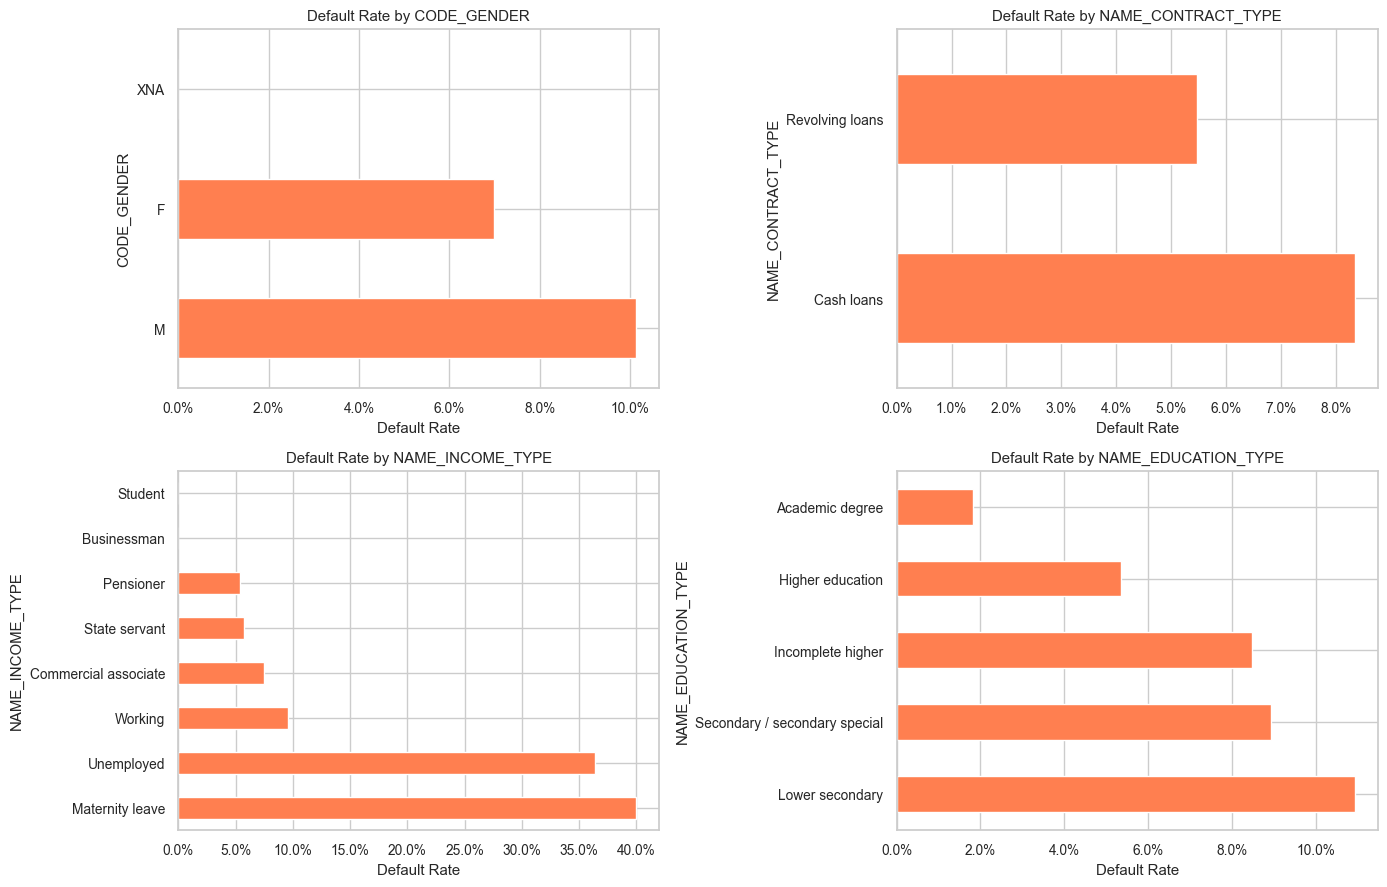

In [ ]:
cat_vars = ['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    rate = app.groupby(var)['TARGET'].mean().sort_values(ascending=False)
    rate.plot(kind='barh', ax=axes[i], color='coral')
    axes[i].set_title(f'Default Rate by {var}')
    axes[i].set_xlabel('Default Rate')
    axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.tight_layout()
plt.show()

## A4. Correlation Heatmap

Top Features Correlated with Default:
  TARGET                                   +1.000
  EXT_SOURCE_1                             -0.155
  DAYS_BIRTH                               +0.078
  REGION_RATING_CLIENT_W_CITY              +0.061
  REGION_RATING_CLIENT                     +0.059
  DAYS_LAST_PHONE_CHANGE                   +0.055
  DAYS_ID_PUBLISH                          +0.051
  REG_CITY_NOT_WORK_CITY                   +0.051
  FLAG_EMP_PHONE                           +0.046
  DAYS_EMPLOYED                            -0.045


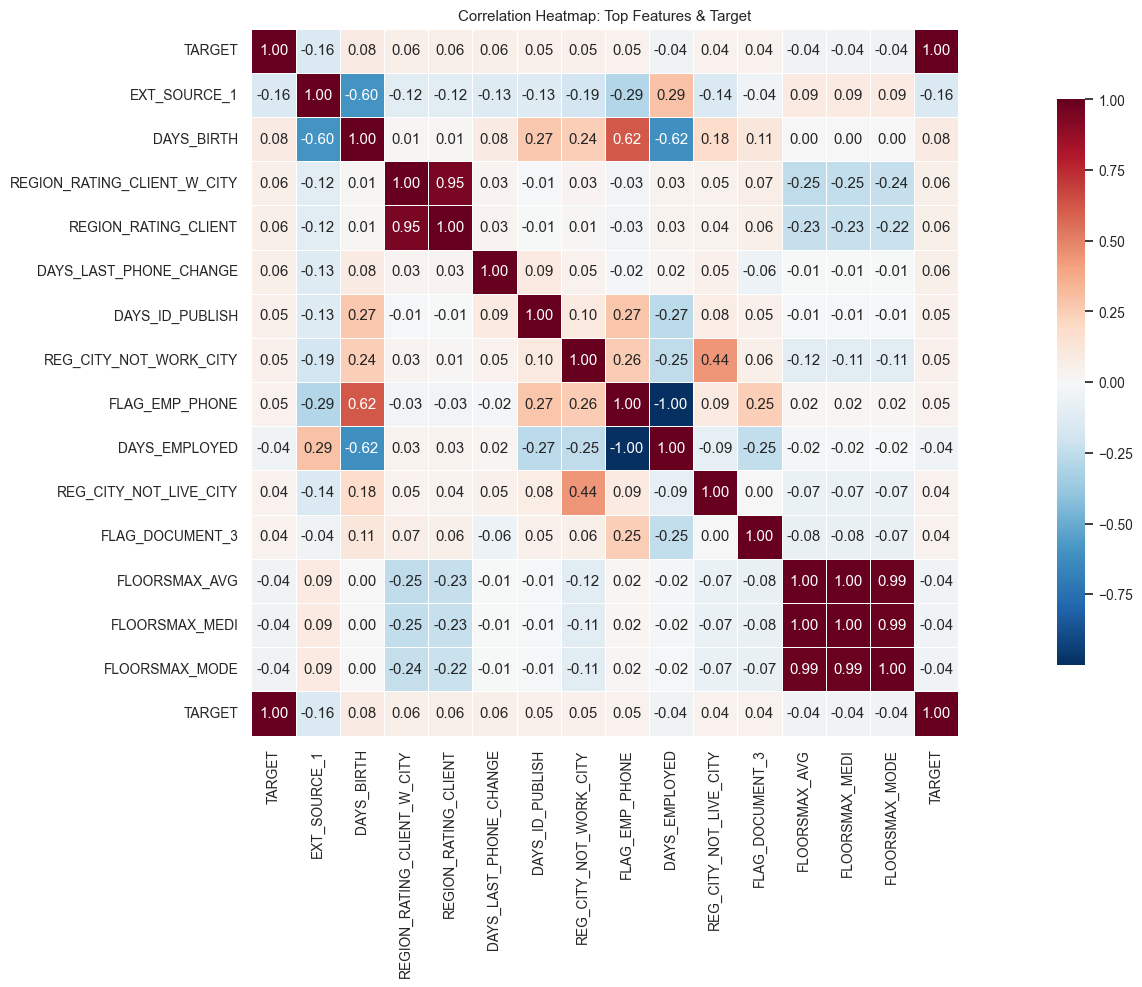

In [ ]:
numeric_cols = app.select_dtypes(include=[np.number]).columns
corr_with_target = app[numeric_cols].corrwith(app['TARGET']).sort_values(ascending=False, key=abs)
corr_with_target = corr_with_target[corr_with_target.abs() > 0.02]

print("Top Features Correlated with Default:")
for feat, corr in corr_with_target.head(10).items():
    print(f"  {feat:40s} {corr:+.3f}")

top_features = corr_with_target.head(15).index.tolist()
corr_matrix = app[top_features + ['TARGET']].corr()

plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap: Top Features & Target')
plt.tight_layout()
plt.show()

---
# Part B: Bureau Data Analysis

## B1. Overview

In [ ]:
print(f"Unique applicants:     {bureau['SK_ID_CURR'].nunique():,}")
print(f"Total credit records:  {len(bureau):,}")
print(f"Avg records/applicant: {len(bureau)/bureau['SK_ID_CURR'].nunique():.1f}")

print("\nData Types & Missing:")
bureau_info = pd.DataFrame({
    'dtype': bureau.dtypes,
    'non_null': bureau.count(),
    'null_pct': bureau.isnull().mean() * 100
})
print(bureau_info)

Unique applicants:     305,811
Total credit records:  1,716,428
Avg records/applicant: 5.6

Data Types & Missing:
                          dtype  non_null   null_pct
SK_ID_CURR                int64   1716428   0.000000
SK_ID_BUREAU              int64   1716428   0.000000
CREDIT_ACTIVE            object   1716428   0.000000
CREDIT_CURRENCY          object   1716428   0.000000
DAYS_CREDIT               int64   1716428   0.000000
CREDIT_DAY_OVERDUE        int64   1716428   0.000000
DAYS_CREDIT_ENDDATE     float64   1610875   6.149573
DAYS_ENDDATE_FACT       float64   1082775  36.916958
AMT_CREDIT_MAX_OVERDUE  float64    591940  65.513264
CNT_CREDIT_PROLONG        int64   1716428   0.000000
AMT_CREDIT_SUM          float64   1716415   0.000757
AMT_CREDIT_SUM_DEBT     float64   1458759  15.011932
AMT_CREDIT_SUM_LIMIT    float64   1124648  34.477415
AMT_CREDIT_SUM_OVERDUE  float64   1716428   0.000000
CREDIT_TYPE              object   1716428   0.000000
DAYS_CREDIT_UPDATE        int64   1716

## B2. Credit Status Distribution

Credit Status Counts:
  Closed                1,079,273 (62.9%)
  Active                  630,607 (36.7%)
  Sold                      6,527 (0.4%)
  Bad debt                     21 (0.0%)


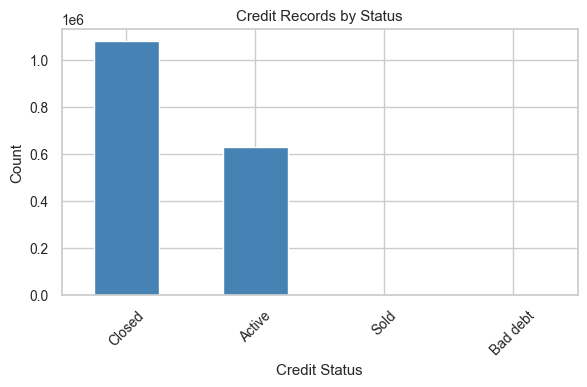

In [ ]:
status_counts = bureau['CREDIT_ACTIVE'].value_counts()
print("Credit Status Counts:")
for status, count in status_counts.items():
    print(f"  {status:20s} {count:>10,} ({count/len(bureau)*100:.1f}%)")

plt.figure(figsize=(6, 4))
status_counts.plot(kind='bar', color='steelblue')
plt.title('Credit Records by Status')
plt.xlabel('Credit Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## B3. Bureau Patterns by Target

Avg Bureau Metrics by Target:
        SK_ID_CURR  num_loans  num_records  avg_credit_amt  avg_overdue
TARGET                                                                 
0        278199.64       5.56         5.56       383230.74      5024.77
1        277168.49       5.62         5.62       316600.96      7799.73


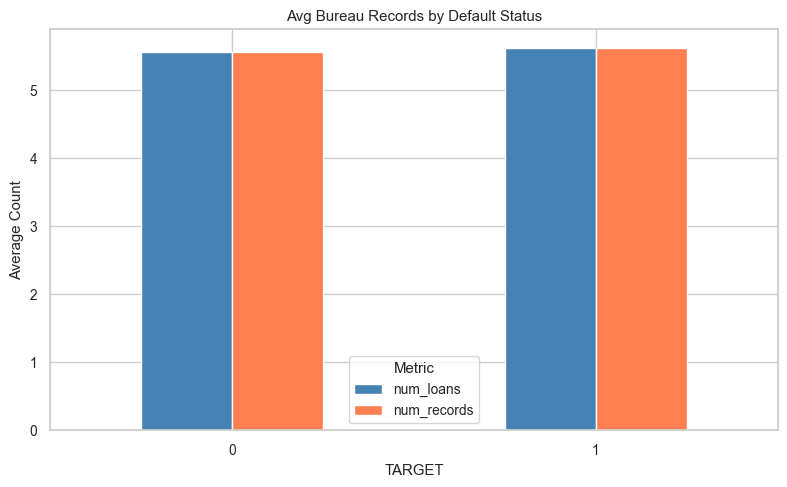

In [ ]:
# Aggregate bureau data to applicant level
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    num_loans=('SK_ID_BUREAU', 'nunique'),
    num_records=('SK_ID_BUREAU', 'count'),
    avg_credit_amt=('AMT_CREDIT_SUM', 'mean'),
    avg_overdue=('AMT_CREDIT_MAX_OVERDUE', 'mean')
).reset_index()

bureau_merged = bureau_agg.merge(app[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')

print("Avg Bureau Metrics by Target:")
print(bureau_merged.groupby('TARGET').mean().round(2))

plt.figure(figsize=(8, 5))
bureau_merged.groupby('TARGET')[['num_loans', 'num_records']].mean().plot(
    kind='bar', ax=plt.gca(), color=['steelblue', 'coral'])
plt.title('Avg Bureau Records by Default Status')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

---
## Key Findings

### Application Data

| Aspect | Observation |
|--------|-------------|
| **Class Imbalance** | ~8% default rate (11.4:1) — requires SMOTE or class weights |
| **Missing Data** | 40+ columns have >50% missing values — see drop recommendations below |
| **Key Predictors** | `EXT_SOURCE_1`, `DAYS_BIRTH`, `REGION_RATING_CLIENT`, `DAYS_EMPLOYED` show strongest correlation with target |
| **Redundant Features** | `_AVG`, `_MODE`, `_MEDI` suffix columns are near-duplicates — keep one variant only |

**Possible Data Anomalies:**

| Column | Anomaly | Details | Fix |
|--------|---------|---------|-----|
| All `DAYS_*` columns | Negative convention | Negative = "days ago" (counterintuitive) — e.g., `DAYS_BIRTH = -10,000` means born 10,000 days ago | Take absolute value for interpretability |
| `DAYS_EMPLOYED` | Positive values (55,374 rows) | Max = 365,243 — breaks even the negative convention; this value encodes "unemployed" | Take absolute value, then replace `365,243` with NaN |
| `AMT_INCOME_TOTAL` | Right-skewed | Max = 117,000,000 — valid but extreme (high-income applicants) | Consider log transform or winsorise for modeling stability |
| `CNT_CHILDREN` | Long tail | Max = 19 — valid but rare; may affect model if not handled | Consider capping or binning for scorecard grouping |

**Recommended columns to drop:**

| Reason | Columns |
|--------|---------|
| >70% missing | `OWN_CAR_AGE` |
| Redundant building area cols (_AVG, _MODE, _MEDI) | `COMMONAREA_*`, `LIVINGAPARTMENTS_*`, `NONLIVINGAPARTMENTS_*`, `LIVINGAREA_*`, `NONLIVINGAREA_*`, `LANDAREA_*`, `FLOORSMAX_*`, `FLOORSMIN_*`, `ELEVATORS_*`, `ENTRANCES_*`, `BASEMENTAREA_*`, `YEARS_BUILD_*`, `YEARS_BEGINEXPLUATATION_*`, `APARTMENTS_*` (all 3 variants) |
| Low-variance flags | `FLAG_MOBIL`, `FLAG_CONT_MOBILE`, `FLAG_EMP_PHONE`, `FLAG_WORK_PHONE`, `FLAG_PHONE`, `FLAG_EMAIL` |
| Document flags (sparse) | `FLAG_DOCUMENT_4` to `FLAG_DOCUMENT_21` (keep `FLAG_DOCUMENT_3` — has signal) |
| Credit bureau request freq (sparse) | `AMT_REQ_CREDIT_BUREAU_HOUR`, `AMT_REQ_CREDIT_BUREAU_DAY`, `AMT_REQ_CREDIT_BUREAU_WEEK` |
| Social circle defaults | `DEF_30_CNT_SOCIAL_CIRCLE`, `DEF_60_CNT_SOCIAL_CIRCLE` |

### Bureau Data

| Aspect | Observation |
|--------|-------------|
| **Scale** | 1.7M credit records across 306K applicants (~5.6 records per applicant) |
| **Credit Status** | Mix of Active, Closed, Sold — distribution informs credit behaviour patterns |
| **Default Signal** | Defaulters have more credit records and higher overdue amounts on average |
| **Next Step** | Aggregate to applicant level (count, mean, max, sum) before merging with application data |

**Possible Data Anomalies:**

| Column | Anomaly | Details | Fix |
|--------|---------|---------|-----|
| `DAYS_CREDIT_ENDDATE` | Positive values (602,603 rows) | Max = 31,199 — future end dates are invalid under any convention | Cap at 0 or replace with NaN |
| `DAYS_CREDIT_UPDATE` | Positive values (17 rows) | Max = 372 — future update dates are invalid | Cap at 0 |
| `AMT_CREDIT_SUM` | Extreme outlier | Max = 585,000,000 — verify if realistic | Winsorise or cap at 99th percentile |
| `CREDIT_DAY_OVERDUE` | Extreme max | Max = 2,792 days (~7.6 years overdue) — possible but extreme | Winsorise or cap |

**Recommended bureau aggregations:**

| Aggregation | Features |
|-------------|----------|
| Count | `num_active_loans`, `num_closed_loans`, `num_sold_loans`, `total_loans` |
| Mean | `avg_credit_amount`, `avg_overdue`, `avg_days_credit`, `avg_annuity` |
| Max | `max_overdue`, `max_credit_amount`, `max_days_overdue` |
| Sum | `total_credit_amount`, `total_debt`, `total_overdue` |

**Derived Ratios:**

| Ratio | Formula | Signal |
|-------|---------|--------|
| Debt-to-Credit | `total_debt / total_credit_amount` | How much of borrowed credit remains unpaid |
| Overdue-to-Debt | `total_overdue / total_debt` | Proportion of outstanding debt that is delinquent |
| Credit Utilization | `total_debt / total_credit_limit` | How much of available credit is being used |
| Prolongation Rate | `sum(CNT_CREDIT_PROLONG) / total_loans` | Frequency of loan extensions (distress signal) |
| Overdue Frequency | `count(loans with overdue) / total_loans` | Proportion of loans that had late payments |